# Gráficos — Resultados del nodo sensor

Este cuaderno lee la tabla **`lecturas`** desde **`nodo_sensor.db`** (misma carpeta que el notebook o ajusta la ruta en la siguiente celda) y genera figuras para el **informe**.

**Requisitos:** `pandas`, `matplotlib`. Si no los tenés en el venv:

```powershell
pip install pandas matplotlib
```

En VS Code / Cursor: elegí el kernel **Python del `.venv`** del proyecto.

In [1]:
from pathlib import Path

# Ruta al SQLite (cambia si tu archivo tiene otro nombre)
DB_PATH = Path("nodo_sensor.db")

if not DB_PATH.exists():
    raise FileNotFoundError(
        f"No se encuentra {DB_PATH.resolve()}. "
        "Abrí el notebook desde la carpeta 'Nodo Sensor' o corrige DB_PATH."
    )
print("Base de datos:", DB_PATH.resolve())

Base de datos: C:\Users\ACER NITRO\Downloads\Nodo Sensor\nodo_sensor.db


In [2]:
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd

con = sqlite3.connect(DB_PATH)
df = pd.read_sql_query(
    "SELECT id, ts, temperatura_c, humedad_pct FROM lecturas ORDER BY id",
    con,
)
con.close()

df["tiempo"] = pd.to_datetime(df["ts"])
print(f"Filas cargadas: {len(df)}")
df.head()

Filas cargadas: 365


,id,ts,temperatura_c,humedad_pct,tiempo
0,1,2026-05-02T18:25:08,394.32,35.38,2026-05-02 18:25:08
1,2,2026-05-02T18:25:23,477.60,62.60,2026-05-02 18:25:23
2,3,2026-05-02T18:25:38,102.68,25.07,2026-05-02 18:25:38
3,4,2026-05-02T18:25:53,910.00,85.86,2026-05-02 18:25:53
4,5,2026-05-02T18:26:08,285.07,89.39,2026-05-02 18:26:08


In [6]:
# Resumen estadístico (útil para la tabla del informe)
stats = df[["temperatura_c", "humedad_pct"]].agg(["count", "min", "max", "mean", "std"]).round(2)
stats.index = ["n lecturas", "Mínimo", "Máximo", "Media", "Desv. estándar"]
stats.columns = ["Temperatura (°C)", "Humedad relativa (%)"]
print("Tabla 1. Estadísticos descriptivos de la corrida\n")
print(stats.to_markdown())

# Advertencia si la temperatura supera valores físicos posibles
if df["temperatura_c"].max() > 100:
    print("\nNOTA: El máximo de temperatura supera valores ambientales realistas.")
    print("Revisar el rango configurado en CounterFit (Random Min/Max) para la corrida reportada.")

Tabla 1. Estadísticos descriptivos de la corrida

|                |   Temperatura (°C) |   Humedad relativa (%) |
|:---------------|-------------------:|-----------------------:|
| n lecturas     |             365    |                 365    |
| Mínimo         |               9.3  |                   0.14 |
| Máximo         |             998.89 |                  99.94 |
| Media          |             485.89 |                  51.79 |
| Desv. estándar |             287.36 |                  28.1  |

NOTA: El máximo de temperatura supera valores ambientales realistas.
Revisar el rango configurado en CounterFit (Random Min/Max) para la corrida reportada.


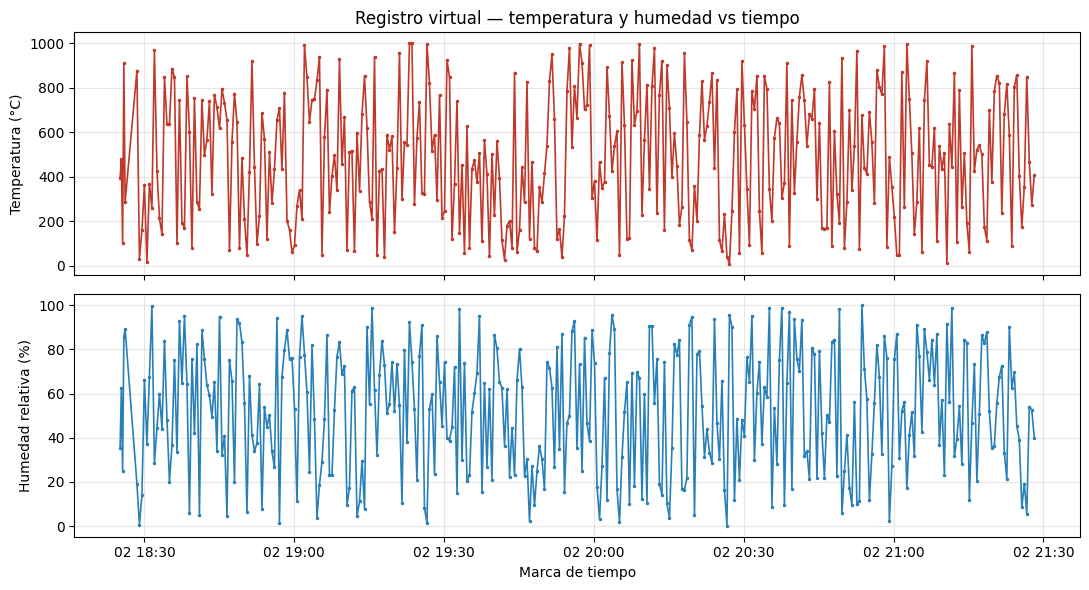

In [3]:
# Figura 1: series temporales (dos paneles)
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(df["tiempo"], df["temperatura_c"], color="#c0392b", linewidth=1.2, marker=".", markersize=3)
axes[0].set_ylabel("Temperatura (°C)")
axes[0].set_title("Registro virtual — temperatura y humedad vs tiempo")
axes[0].grid(True, alpha=0.3)

axes[1].plot(df["tiempo"], df["humedad_pct"], color="#2980b9", linewidth=1.2, marker=".", markersize=3)
axes[1].set_ylabel("Humedad relativa (%)")
axes[1].set_xlabel("Marca de tiempo")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

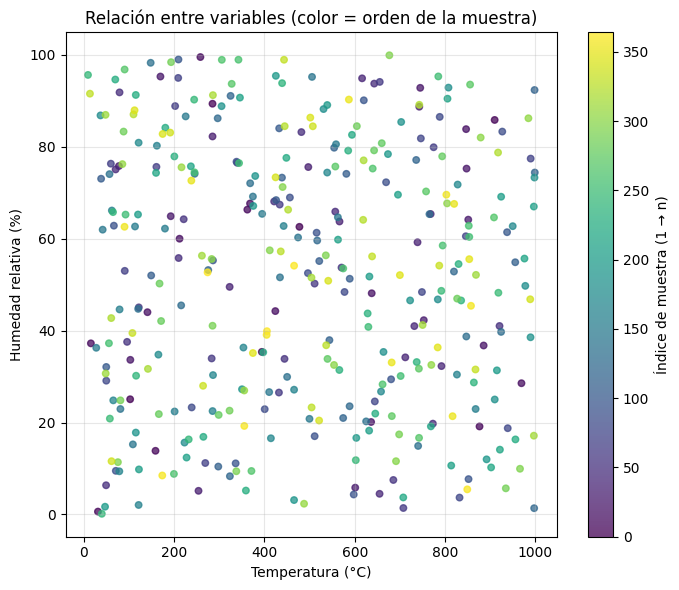

In [4]:
# Figura 2: dispersión humedad vs temperatura (color = tiempo)
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(
    df["temperatura_c"],
    df["humedad_pct"],
    c=range(len(df)),
    cmap="viridis",
    alpha=0.75,
    s=22,
)
ax.set_xlabel("Temperatura (°C)")
ax.set_ylabel("Humedad relativa (%)")
ax.set_title("Relación entre variables (color = orden de la muestra)")
plt.colorbar(sc, ax=ax, label="Índice de muestra (1 → n)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

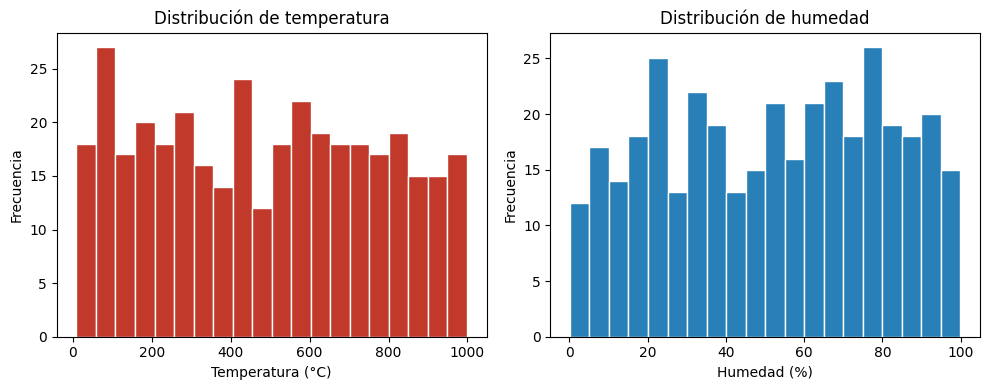

In [5]:
# Figura 3: histogramas
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(df["temperatura_c"], bins=20, color="#c0392b", edgecolor="white")
axes[0].set_xlabel("Temperatura (°C)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de temperatura")

axes[1].hist(df["humedad_pct"], bins=20, color="#2980b9", edgecolor="white")
axes[1].set_xlabel("Humedad (%)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de humedad")

plt.tight_layout()
plt.show()

## Exportar figuras para el informe (PNG)

La **celda siguiente** guarda tres archivos en la carpeta **`figuras_informe/`**:
`series_temporales.png`, `dispersion.png`, `histogramas.png` (150 dpi). Ejecutala después de cargar `df`.

In [ ]:
# Opcional: guardar las tres figuras como PNG para pegar en el informe
from pathlib import Path

out_dir = Path("figuras_informe")
out_dir.mkdir(exist_ok=True)

fig1, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(df["tiempo"], df["temperatura_c"], color="#c0392b", linewidth=1.2, marker=".", markersize=3)
axes[0].set_ylabel("Temperatura (C)")
axes[0].set_title("Temperatura y humedad vs tiempo")
axes[0].grid(True, alpha=0.3)
axes[1].plot(df["tiempo"], df["humedad_pct"], color="#2980b9", linewidth=1.2, marker=".", markersize=3)
axes[1].set_ylabel("Humedad relativa (%)")
axes[1].set_xlabel("Marca de tiempo")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
fig1.savefig(out_dir / "series_temporales.png", dpi=150)
plt.close(fig1)

fig2, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(df["temperatura_c"], df["humedad_pct"], c=range(len(df)), cmap="viridis", alpha=0.75, s=22)
ax.set_xlabel("Temperatura (C)")
ax.set_ylabel("Humedad relativa (%)")
ax.set_title("Relacion entre variables")
plt.colorbar(sc, ax=ax, label="Indice de muestra")
plt.tight_layout()
fig2.savefig(out_dir / "dispersion.png", dpi=150)
plt.close(fig2)

fig3, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(df["temperatura_c"], bins=20, color="#c0392b", edgecolor="white")
axes[0].set_xlabel("Temperatura (C)")
axes[0].set_ylabel("Frecuencia")
axes[1].hist(df["humedad_pct"], bins=20, color="#2980b9", edgecolor="white")
axes[1].set_xlabel("Humedad (%)")
axes[1].set_ylabel("Frecuencia")
plt.tight_layout()
fig3.savefig(out_dir / "histogramas.png", dpi=150)
plt.close(fig3)

print("Guardado en:", out_dir.resolve())